# 01 - Universal Audio Preprocessing

**Cycle Rack Audio Classification Project**

This notebook implements universal preprocessing techniques that will be applied to all audio data regardless of the final model type (Classical ML or CNN).

## Preprocessing Pipeline:
1. **Resampling**: Standardize sample rate to 16kHz
2. **Amplitude Normalization**: Standardize volume levels
3. **Framing/Windowing**: Apply windowing for spectral analysis
4. **Silence Removal/Trimming**: Remove silent segments using energy thresholding

## Dataset Structure:
- Background noise: 1,300 clips
- Angle grinder sounds: 18 clips
- Other power tools: Variable count

In [1]:
pip install librosa pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 36.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 29.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 39.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [librosa]7/19 [seaborn]ib]n]
Note: you may need to restart the kernel to use updated packages.


In [13]:
# Import required libraries
import os
import glob
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import get_window
import soundfile as sf
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Configuration and Parameters

In [14]:
# Configuration parameters
CONFIG = {
    # Data paths
    'RAW_DATA_PATH': '../data/raw/',
    'PROCESSED_DATA_PATH': '../data/processed/',
    
    # Audio preprocessing parameters
    'SAMPLE_RATE': 16000,  # 16kHz standard for speech/environmental audio
    'DURATION': None,      # Keep original duration (set to float for fixed length)
    
    # Normalization parameters
    'NORM_TYPE': 'rms',    # 'peak' or 'rms' normalization
    'TARGET_RMS_DB': -20,  # Target RMS level in dB
    
    # Silence removal parameters
    'SILENCE_THRESHOLD_DB': 20,  # dB below max for silence detection
    'MIN_SILENCE_DURATION': 0.1, # Minimum silence duration to remove (seconds)
    
    # Windowing parameters
    'WINDOW_TYPE': 'hann',       # Window type for framing
    'WINDOW_LENGTH': 2048,       # Window length in samples
    'HOP_LENGTH': 512,           # Hop length in samples
    
    # Quality control
    'MIN_DURATION': 0.5,         # Minimum clip duration (seconds)
    'MAX_DURATION': 200,        # Maximum clip duration (seconds)
}

# Create output directories
os.makedirs(CONFIG['PROCESSED_DATA_PATH'], exist_ok=True)
for subfolder in ['background', 'angle_grinder', 'other_power_tools']:
    os.makedirs(os.path.join(CONFIG['PROCESSED_DATA_PATH'], subfolder), exist_ok=True)

print("Configuration loaded:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration loaded:
  RAW_DATA_PATH: ../data/raw/
  PROCESSED_DATA_PATH: ../data/processed/
  SAMPLE_RATE: 16000
  DURATION: None
  NORM_TYPE: rms
  TARGET_RMS_DB: -20
  SILENCE_THRESHOLD_DB: 20
  MIN_SILENCE_DURATION: 0.1
  WINDOW_TYPE: hann
  WINDOW_LENGTH: 2048
  HOP_LENGTH: 512
  MIN_DURATION: 0.5
  MAX_DURATION: 200


## Data Discovery and Analysis

In [15]:
def discover_audio_files(data_path):
    """
    Discover all audio files in the dataset and analyze their properties.
    
    Args:
        data_path (str): Path to the raw data directory
    
    Returns:
        dict: Dictionary containing file paths organized by class
    """
    audio_extensions = ['*.wav', '*.mp3', '*.flac', '*.aac', '*.ogg']
    file_info = {
        'background': [],
        'angle_grinder': [],
        'other_power_tools': []
    }
    
    for class_name in file_info.keys():
        class_path = os.path.join(data_path, class_name)
        if os.path.exists(class_path):
            for ext in audio_extensions:
                files = glob.glob(os.path.join(class_path, ext))
                file_info[class_name].extend(files)
    
    return file_info

def analyze_audio_properties(file_paths, max_files=10):
    """
    Analyze properties of a sample of audio files.
    
    Args:
        file_paths (list): List of audio file paths
        max_files (int): Maximum number of files to analyze
    
    Returns:
        pd.DataFrame: DataFrame with audio file properties
    """
    properties = []
    sample_files = file_paths[:max_files] if len(file_paths) > max_files else file_paths
    
    for file_path in tqdm(sample_files, desc="Analyzing audio properties"):
        try:
            # Get file info without loading full audio
            info = sf.info(file_path)
            duration = info.duration
            sample_rate = info.samplerate
            channels = info.channels
            
            # Load a small portion to check amplitude
            y, sr = librosa.load(file_path, sr=None, duration=min(5.0, duration))
            rms = librosa.feature.rms(y=y)[0].mean()
            max_amplitude = np.max(np.abs(y))
            
            properties.append({
                'file_path': os.path.basename(file_path),
                'duration': duration,
                'sample_rate': sample_rate,
                'channels': channels,
                'rms': rms,
                'max_amplitude': max_amplitude,
                'file_size_mb': os.path.getsize(file_path) / (1024*1024)
            })
            
        except Exception as e:
            print(f"Error analyzing {file_path}: {e}")
    
    return pd.DataFrame(properties)

# Discover audio files
audio_files = discover_audio_files(CONFIG['RAW_DATA_PATH'])

print("Dataset Overview:")
for class_name, files in audio_files.items():
    print(f"  {class_name}: {len(files)} files")

# Analyze sample of files from each class
analysis_results = {}
for class_name, files in audio_files.items():
    if files:
        print(f"\nAnalyzing {class_name} samples...")
        analysis_results[class_name] = analyze_audio_properties(files, max_files=5)
        display(analysis_results[class_name])

Dataset Overview:
  background: 1346 files
  angle_grinder: 30 files
  other_power_tools: 24 files

Analyzing background samples...


Analyzing audio properties: 100%|██████████| 5/5 [00:00<00:00, 2515.78it/s]


,file_path,duration,sample_rate,channels,rms,max_amplitude,file_size_mb
0,chunk_1304.wav,3.0,16000,1,0.070955,0.443878,0.091595
1,chunk_874.wav,3.0,16000,1,0.033071,0.152985,0.091595
2,chunk_860.wav,3.0,16000,1,0.036011,0.174011,0.091595
3,chunk_1310.wav,3.0,16000,1,0.072772,1.000000,0.091595
4,chunk_1338.wav,3.0,16000,1,0.167251,0.663910,0.091595



Analyzing angle_grinder samples...


Analyzing audio properties: 100%|██████████| 5/5 [00:00<00:00, 232.87it/s]


,file_path,duration,sample_rate,channels,rms,max_amplitude,file_size_mb
0,412255__mehdiikazemi__angle-grinder.wav,37.740000,48000,2,0.063464,0.515610,6.941650
1,339147__beethovenboy__angle-grinder_cutting-co...,166.504490,44100,2,0.005781,0.098935,42.016769
2,347446__kinoton__angle-grinder-onoff-grinding.wav,41.335813,48000,1,0.038458,0.350366,5.690020
3,324724__150112__anglegrinder.wav,11.424000,48000,1,0.039078,0.423362,1.576527
4,366603__jittels__grinding-wood.wav,31.657667,48000,2,0.021069,0.242822,8.695740



Analyzing other_power_tools samples...


Analyzing audio properties: 100%|██████████| 5/5 [00:00<00:00, 176.44it/s]


,file_path,duration,sample_rate,channels,rms,max_amplitude,file_size_mb
0,carpenter-using-a-drill-while-working-001-3206...,34.993958,48000,2,0.200243,0.886658,6.407627
1,angle-grinder-313298.wav,41.426667,44100,2,0.124211,0.832062,6.969173
2,air_powertool-35837.wav,35.514000,24000,2,0.083178,0.804291,3.251446
3,bench-drillwood-drilling-320672.wav,35.521958,48000,2,0.096185,0.614670,6.504307
4,drill-200178.mp3,37.579206,44100,2,0.066912,0.498036,1.145567


## Preprocessing Functions

In [16]:
def resample_audio(y, orig_sr, target_sr=16000):
    """
    Resample audio to target sample rate.
    
    Args:
        y (np.array): Audio time series
        orig_sr (int): Original sample rate
        target_sr (int): Target sample rate
    
    Returns:
        np.array: Resampled audio
    """
    if orig_sr != target_sr:
        y = librosa.resample(y, orig_sr=orig_sr, target_sr=target_sr)
    return y

def normalize_audio(y, method='rms', target_db=-20):
    """
    Normalize audio amplitude.
    
    Args:
        y (np.array): Audio time series
        method (str): Normalization method ('peak' or 'rms')
        target_db (float): Target level in dB
    
    Returns:
        np.array: Normalized audio
    """
    if method == 'peak':
        # Peak normalization
        peak = np.max(np.abs(y))
        if peak > 0:
            target_linear = 10**(target_db/20)
            y = y * (target_linear / peak)
    
    elif method == 'rms':
        # RMS normalization
        rms = np.sqrt(np.mean(y**2))
        if rms > 0:
            target_linear = 10**(target_db/20)
            y = y * (target_linear / rms)
    
    # Prevent clipping
    max_val = np.max(np.abs(y))
    if max_val > 1.0:
        y = y / max_val * 0.95
    
    return y

def remove_silence(y, sr, top_db=20, frame_length=2048, hop_length=512):
    """
    Remove silence from beginning and end of audio.
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        top_db (float): dB threshold for silence detection
        frame_length (int): Frame length for analysis
        hop_length (int): Hop length for analysis
    
    Returns:
        np.array: Trimmed audio
    """
    # Use librosa's trim function
    y_trimmed, _ = librosa.effects.trim(
        y, 
        top_db=top_db,
        frame_length=frame_length,
        hop_length=hop_length
    )
    
    return y_trimmed

def apply_windowing(y, window_type='hann', window_length=2048, hop_length=512):
    """
    Apply windowing function for spectral analysis preparation.
    This function prepares the audio for downstream spectral feature extraction.
    
    Args:
        y (np.array): Audio time series
        window_type (str): Type of window function
        window_length (int): Window length in samples
        hop_length (int): Hop length in samples
    
    Returns:
        dict: Dictionary containing windowing parameters for later use
    """
    # Store windowing parameters for consistency in feature extraction
    windowing_params = {
        'window_type': window_type,
        'window_length': window_length,
        'hop_length': hop_length,
        'n_fft': window_length  # Use window length as n_fft
    }
    
    return y, windowing_params

def validate_audio_quality(y, sr, min_duration=0.5, max_duration=30.0):
    """
    Validate audio quality and duration.
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        min_duration (float): Minimum acceptable duration
        max_duration (float): Maximum acceptable duration
    
    Returns:
        bool: True if audio passes quality checks
        dict: Dictionary with quality metrics
    """
    duration = len(y) / sr
    max_amplitude = np.max(np.abs(y))
    rms = np.sqrt(np.mean(y**2))
    
    quality_metrics = {
        'duration': duration,
        'max_amplitude': max_amplitude,
        'rms': rms,
        'snr_estimate': 20 * np.log10(rms) if rms > 0 else -np.inf
    }
    
    # Quality checks
    checks = {
        'duration_ok': min_duration <= duration <= max_duration,
        'amplitude_ok': max_amplitude > 1e-6,  # Not completely silent
        'rms_ok': rms > 1e-6,  # Has some energy
        'no_clipping': max_amplitude < 0.99  # Not heavily clipped
    }
    
    passed = all(checks.values())
    quality_metrics['checks'] = checks
    quality_metrics['passed'] = passed
    
    return passed, quality_metrics

print("Preprocessing functions defined successfully!")

Preprocessing functions defined successfully!


## Main Preprocessing Pipeline

In [17]:
def preprocess_audio_file(input_path, output_path, config):
    """
    Complete preprocessing pipeline for a single audio file.
    
    Args:
        input_path (str): Path to input audio file
        output_path (str): Path to save processed audio
        config (dict): Configuration parameters
    
    Returns:
        dict: Processing results and metadata
    """
    try:
        # Load audio
        y, orig_sr = librosa.load(input_path, sr=None, duration=config['DURATION'])
        
        # Store original properties
        orig_duration = len(y) / orig_sr
        orig_max_amp = np.max(np.abs(y))
        orig_rms = np.sqrt(np.mean(y**2))
        
        # Step 1: Resample to target sample rate
        y = resample_audio(y, orig_sr, config['SAMPLE_RATE'])
        sr = config['SAMPLE_RATE']
        
        # Step 2: Remove silence
        y = remove_silence(
            y, sr, 
            top_db=config['SILENCE_THRESHOLD_DB'],
            frame_length=config['WINDOW_LENGTH'],
            hop_length=config['HOP_LENGTH']
        )
        
        # Step 3: Normalize amplitude
        y = normalize_audio(
            y, 
            method=config['NORM_TYPE'],
            target_db=config['TARGET_RMS_DB']
        )
        
        # Step 4: Apply windowing preparation
        y, windowing_params = apply_windowing(
            y,
            window_type=config['WINDOW_TYPE'],
            window_length=config['WINDOW_LENGTH'],
            hop_length=config['HOP_LENGTH']
        )
        
        # Step 5: Validate quality
        passed, quality_metrics = validate_audio_quality(
            y, sr,
            min_duration=config['MIN_DURATION'],
            max_duration=config['MAX_DURATION']
        )
        
        if passed:
            # Save processed audio
            sf.write(output_path, y, sr)
            
            # Create processing report
            processing_report = {
                'input_file': os.path.basename(input_path),
                'output_file': os.path.basename(output_path),
                'success': True,
                'original_sr': orig_sr,
                'target_sr': sr,
                'original_duration': orig_duration,
                'processed_duration': quality_metrics['duration'],
                'duration_change': quality_metrics['duration'] - orig_duration,
                'original_max_amp': orig_max_amp,
                'processed_max_amp': quality_metrics['max_amplitude'],
                'original_rms': orig_rms,
                'processed_rms': quality_metrics['rms'],
                'windowing_params': windowing_params,
                'quality_passed': passed
            }
        else:
            processing_report = {
                'input_file': os.path.basename(input_path),
                'success': False,
                'error': 'Failed quality validation',
                'quality_checks': quality_metrics['checks']
            }
        
        return processing_report
        
    except Exception as e:
        return {
            'input_file': os.path.basename(input_path),
            'success': False,
            'error': str(e)
        }

def batch_preprocess(audio_files_dict, config):
    """
    Batch preprocessing of all audio files.
    
    Args:
        audio_files_dict (dict): Dictionary of audio files by class
        config (dict): Configuration parameters
    
    Returns:
        pd.DataFrame: Processing results summary
    """
    all_reports = []
    
    for class_name, files in audio_files_dict.items():
        print(f"\nProcessing {class_name} files ({len(files)} total)...")
        
        for file_path in tqdm(files, desc=f"Processing {class_name}"):
            # Create output path
            filename = os.path.basename(file_path)
            name, _ = os.path.splitext(filename)
            output_path = os.path.join(
                config['PROCESSED_DATA_PATH'], 
                class_name, 
                f"{name}_processed.wav"
            )
            
            # Process file
            report = preprocess_audio_file(file_path, output_path, config)
            report['class'] = class_name
            all_reports.append(report)
    
    return pd.DataFrame(all_reports)

print("Main preprocessing pipeline defined!")

Main preprocessing pipeline defined!


## Execute Preprocessing

In [18]:
# Run batch preprocessing
print("Starting batch preprocessing...")
processing_results = batch_preprocess(audio_files, CONFIG)

# Display processing summary
print("\n=== PREPROCESSING SUMMARY ===")
print(f"Total files processed: {len(processing_results)}")
print(f"Successful: {processing_results['success'].sum()}")
print(f"Failed: {(~processing_results['success']).sum()}")

# Summary by class
class_summary = processing_results.groupby('class')['success'].agg(['count', 'sum']).rename(columns={'sum': 'successful'})
class_summary['failed'] = class_summary['count'] - class_summary['successful']
class_summary['success_rate'] = class_summary['successful'] / class_summary['count'] * 100

print("\nSuccess rate by class:")
display(class_summary)

# Save processing results
results_path = os.path.join(CONFIG['PROCESSED_DATA_PATH'], 'preprocessing_results.csv')
processing_results.to_csv(results_path, index=False)
print(f"\nProcessing results saved to: {results_path}")

Starting batch preprocessing...

Processing background files (1346 total)...


Processing background: 100%|██████████| 1346/1346 [00:02<00:00, 474.88it/s]



Processing angle_grinder files (30 total)...


Processing angle_grinder: 100%|██████████| 30/30 [00:01<00:00, 26.06it/s]



Processing other_power_tools files (24 total)...


Processing other_power_tools: 100%|██████████| 24/24 [00:01<00:00, 18.08it/s]


=== PREPROCESSING SUMMARY ===
Total files processed: 1400
Successful: 1399
Failed: 1

Success rate by class:


,count,successful,failed,success_rate
class,,,,
angle_grinder,30,30,0,100.000000
background,1346,1346,0,100.000000
other_power_tools,24,23,1,95.833333



Processing results saved to: ../data/processed/preprocessing_results.csv


## Quality Analysis and Visualization

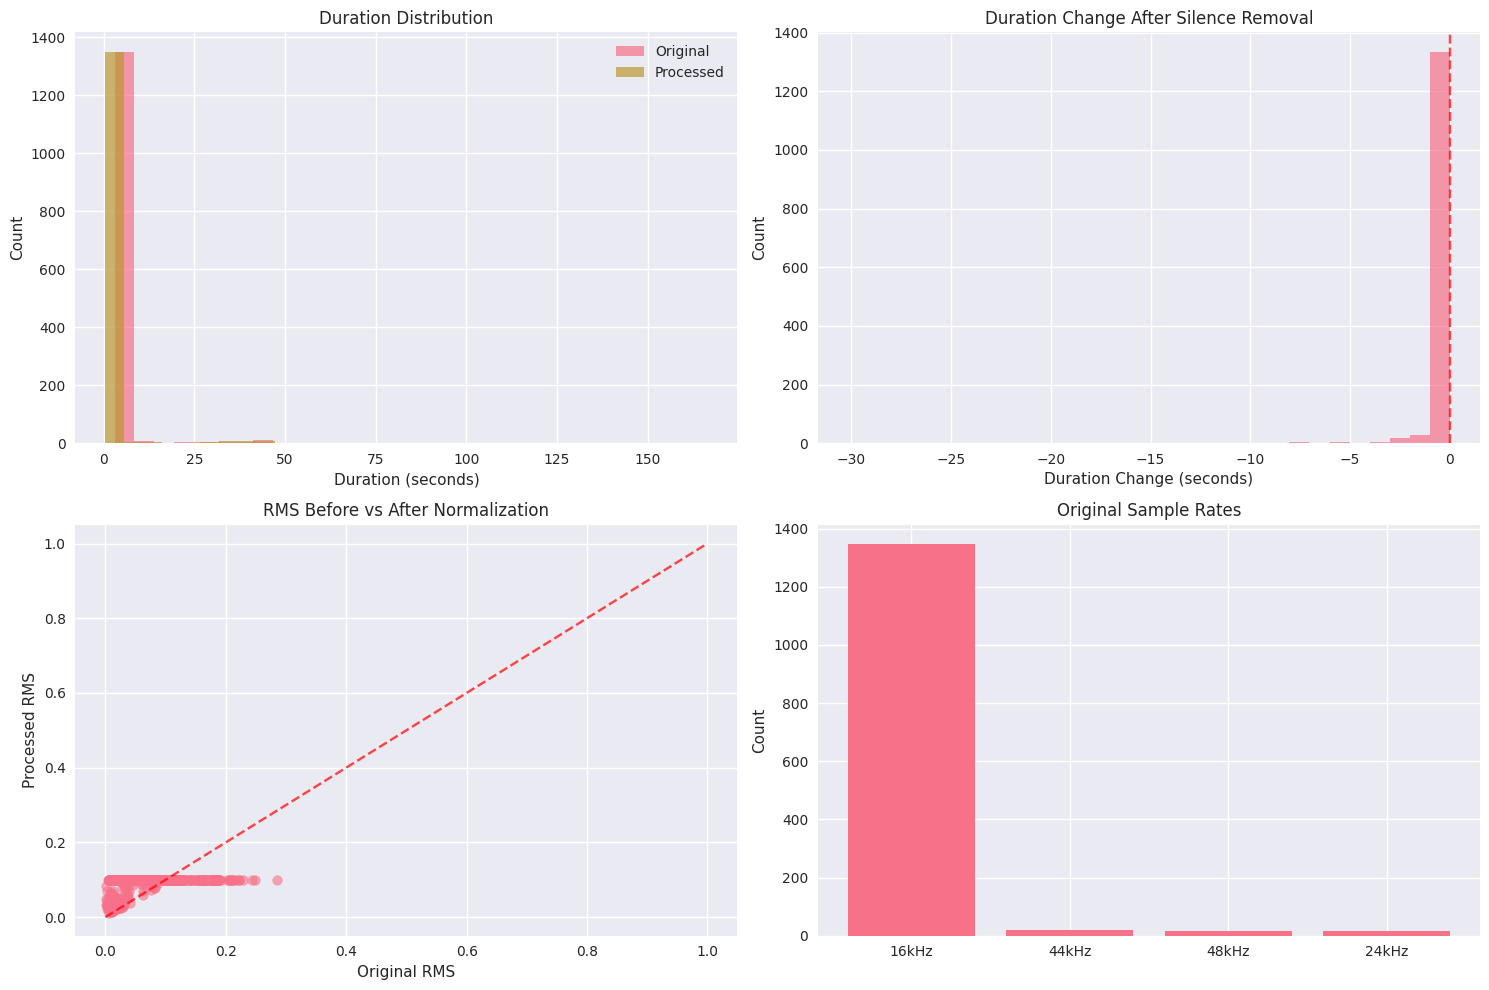


=== PROCESSING STATISTICS ===
Average duration reduction: -0.199 seconds
Max duration reduction: -30.158 seconds
Files with >1s duration reduction: 65

Original sample rate distribution:
  16000 Hz: 1346 files
  44100 Hz: 21 files
  48000 Hz: 17 files
  24000 Hz: 15 files


In [19]:
# Filter successful processing results
successful_results = processing_results[processing_results['success'] == True].copy()

if len(successful_results) > 0:
    # Duration analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Duration before and after processing
    axes[0, 0].hist(successful_results['original_duration'], bins=30, alpha=0.7, label='Original')
    axes[0, 0].hist(successful_results['processed_duration'], bins=30, alpha=0.7, label='Processed')
    axes[0, 0].set_xlabel('Duration (seconds)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Duration Distribution')
    axes[0, 0].legend()
    
    # Duration change
    axes[0, 1].hist(successful_results['duration_change'], bins=30, alpha=0.7)
    axes[0, 1].set_xlabel('Duration Change (seconds)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Duration Change After Silence Removal')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    
    # RMS before and after
    axes[1, 0].scatter(successful_results['original_rms'], successful_results['processed_rms'], alpha=0.6)
    axes[1, 0].plot([0, 1], [0, 1], 'r--', alpha=0.7)  # y=x line
    axes[1, 0].set_xlabel('Original RMS')
    axes[1, 0].set_ylabel('Processed RMS')
    axes[1, 0].set_title('RMS Before vs After Normalization')
    
    # Sample rate distribution
    sr_counts = successful_results['original_sr'].value_counts()
    axes[1, 1].bar(range(len(sr_counts)), sr_counts.values)
    axes[1, 1].set_xticks(range(len(sr_counts)))
    axes[1, 1].set_xticklabels([f"{int(sr/1000)}kHz" for sr in sr_counts.index])
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Original Sample Rates')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n=== PROCESSING STATISTICS ===")
    print(f"Average duration reduction: {successful_results['duration_change'].mean():.3f} seconds")
    print(f"Max duration reduction: {successful_results['duration_change'].min():.3f} seconds")
    print(f"Files with >1s duration reduction: {(successful_results['duration_change'] < -1.0).sum()}")
    
    print(f"\nOriginal sample rate distribution:")
    for sr, count in successful_results['original_sr'].value_counts().items():
        print(f"  {int(sr)} Hz: {count} files")
        
else:
    print("No successful processing results to analyze.")

## Sample Audio Comparison

Comparing: chunk_1304.wav


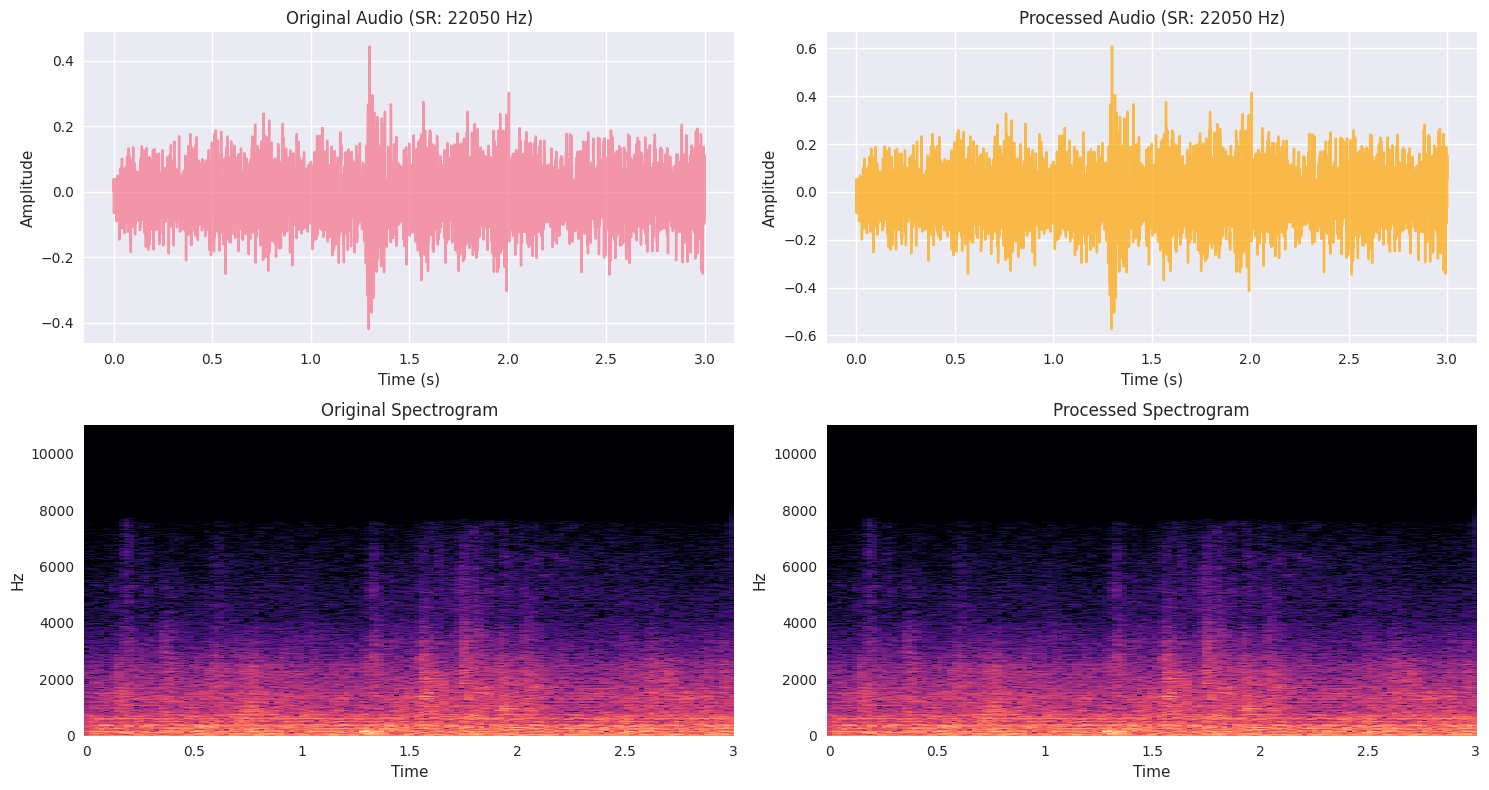

Original - Duration: 3.00s, RMS: 0.0730, Max: 0.4440
Processed - Duration: 3.00s, RMS: 0.1000, Max: 0.6079


In [20]:
def plot_audio_comparison(original_path, processed_path, max_duration=5.0):
    """
    Plot comparison between original and processed audio.
    
    Args:
        original_path (str): Path to original audio file
        processed_path (str): Path to processed audio file
        max_duration (float): Maximum duration to plot (seconds)
    """
    # Load audio files
    y_orig, sr_orig = librosa.load(original_path, duration=max_duration)
    y_proc, sr_proc = librosa.load(processed_path, duration=max_duration)
    
    # Create time axes
    t_orig = np.linspace(0, len(y_orig)/sr_orig, len(y_orig))
    t_proc = np.linspace(0, len(y_proc)/sr_proc, len(y_proc))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    
    # Waveform comparison
    axes[0, 0].plot(t_orig, y_orig, alpha=0.7, label='Original')
    axes[0, 0].set_title(f'Original Audio (SR: {sr_orig} Hz)')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    
    axes[0, 1].plot(t_proc, y_proc, alpha=0.7, label='Processed', color='orange')
    axes[0, 1].set_title(f'Processed Audio (SR: {sr_proc} Hz)')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Amplitude')
    
    # Spectrograms
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    D_proc = librosa.amplitude_to_db(np.abs(librosa.stft(y_proc)), ref=np.max)
    
    librosa.display.specshow(D_orig, sr=sr_orig, x_axis='time', y_axis='hz', ax=axes[1, 0])
    axes[1, 0].set_title('Original Spectrogram')
    
    librosa.display.specshow(D_proc, sr=sr_proc, x_axis='time', y_axis='hz', ax=axes[1, 1])
    axes[1, 1].set_title('Processed Spectrogram')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Original - Duration: {len(y_orig)/sr_orig:.2f}s, RMS: {np.sqrt(np.mean(y_orig**2)):.4f}, Max: {np.max(np.abs(y_orig)):.4f}")
    print(f"Processed - Duration: {len(y_proc)/sr_proc:.2f}s, RMS: {np.sqrt(np.mean(y_proc**2)):.4f}, Max: {np.max(np.abs(y_proc)):.4f}")

# Select a sample file for comparison
if len(successful_results) > 0:
    # Get first successful file from background class
    sample_result = successful_results[successful_results['class'] == 'background'].iloc[0]
    
    # Find original file path
    original_file = None
    for files in audio_files['background']:
        if sample_result['input_file'] in os.path.basename(files):
            original_file = files
            break
    
    if original_file:
        processed_file = os.path.join(CONFIG['PROCESSED_DATA_PATH'], 'background', sample_result['output_file'])
        
        print(f"Comparing: {sample_result['input_file']}")
        plot_audio_comparison(original_file, processed_file)
    else:
        print("Could not find original file for comparison")
else:
    print("No successful results available for comparison")

## Export Processing Metadata

In [21]:
# Create comprehensive metadata for downstream processing
metadata = {
    'preprocessing_config': CONFIG,
    'dataset_summary': {
        'total_files': len(processing_results),
        'successful_files': processing_results['success'].sum(),
        'failed_files': (~processing_results['success']).sum(),
        'classes': list(audio_files.keys()),
        'files_per_class': {k: len(v) for k, v in audio_files.items()}
    },
    'processing_statistics': {
        'avg_duration_change': successful_results['duration_change'].mean() if len(successful_results) > 0 else 0,
        'avg_processed_duration': successful_results['processed_duration'].mean() if len(successful_results) > 0 else 0,
        'sample_rates_processed': list(successful_results['original_sr'].unique()) if len(successful_results) > 0 else []
    }
}

# Save metadata as JSON
import json
metadata_path = os.path.join(CONFIG['PROCESSED_DATA_PATH'], 'preprocessing_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Preprocessing metadata saved to: {metadata_path}")

# Create file manifest for easy access
if len(successful_results) > 0:
    file_manifest = []
    for _, row in successful_results.iterrows():
        file_manifest.append({
            'class': row['class'],
            'filename': row['output_file'],
            'path': os.path.join(CONFIG['PROCESSED_DATA_PATH'], row['class'], row['output_file']),
            'duration': row['processed_duration'],
            'sample_rate': row['target_sr']
        })
    
    manifest_df = pd.DataFrame(file_manifest)
    manifest_path = os.path.join(CONFIG['PROCESSED_DATA_PATH'], 'file_manifest.csv')
    manifest_df.to_csv(manifest_path, index=False)
    print(f"File manifest saved to: {manifest_path}")
    
    print("\n=== PREPROCESSING COMPLETE ===")
    print(f"Processed files available in: {CONFIG['PROCESSED_DATA_PATH']}")
    print("Ready for feature extraction in next notebook (02_classical_features.ipynb)")
else:
    print("\nNo files were successfully processed. Please check the configuration and input data.")

Preprocessing metadata saved to: ../data/processed/preprocessing_metadata.json
File manifest saved to: ../data/processed/file_manifest.csv

=== PREPROCESSING COMPLETE ===
Processed files available in: ../data/processed/
Ready for feature extraction in next notebook (02_classical_features.ipynb)
